we have 3 files to use- adt raw csv
fate readout csv at barcode lvl 
x rna counts mtx 

subset to hsc . find hvgs . 
use the fate readout csv to classify in terms of fate what barcode lineages are unipotent 
broadcast those lineages onto every cell in the barcode lineage
this is the basis of our groups = True in mofa. We will run with some larger groups first- ery / Mast [largest presence iirc] / cDC1 VS multipotent . see wht makes these JUST ery and not multipotent. so run w groups=True for group= i for all i in celltypes . 

to check if this has worked, check the variance explained per factor in the data. 

if it doesnt work: try run on all data and not just hscs 

In [4]:
import pandas as pd
import scanpy as sc 
import numpy as np 

In [5]:
adt_counts = pd.read_csv("/vast/projects/Sisseq/givanna/making_sense_of_files/adt_raw.csv")

print(adt_counts.head())
print(adt_counts.columns.to_list())

# important here -> protein is column , cell is row so (cell x protien)



   Unnamed: 0                cell  Hu.CD134  Hu.CD112  Hu.HLA.DR  Hu.CD115  \
0           1  AAACCCAAGGTTAAAC-1         0        25         19         1   
1           2  AAACCCACAAATCAAG-1         0         8         18         3   
2           3  AAACCCACAAGTATCC-1         0         8          7         0   
3           4  AAACCCACAGGTTACT-1         0         9         13         2   
4           5  AAACCCACATGATCTG-1         0        14          1        13   

   Hu.CD279  Hu.CD37  Hu.CD99  Hu.LOX.1  ...  RNA.weight  ADT.weight  \
0         0        0        9         0  ...    0.529892    0.470108   
1         0        0       16         0  ...    0.603510    0.396490   
2         1        0        5         1  ...    0.657347    0.342653   
3         0        0       13         2  ...    0.423450    0.576550   
4         3        0        3         1  ...    0.525541    0.474459   

   wsnn_res.2  seurat_clusters  wsnn_res.1  predicted.celltype.score  \
0          10             

In [6]:
num_barcodes = adt_counts["cons_bc"].nunique()

print("number of unique barcodes is : ", num_barcodes)

adt_counts["cons_bc"].head() # length of 20. the subsequent analysis has the length to be subset to 15 and donor id to be added here for analysis

number of unique barcodes is :  3066


0    GTCTCGTTCTGGGTGGTAGT
1                     NaN
2                     NaN
3    CCCTGGTTGTCTGTGTTTGT
4    AGGAGGGACATTCAGGGACT
Name: cons_bc, dtype: object

In [7]:
adt_obj = adt_counts

adt_obj["cons_bc"] = adt_counts["cons_bc"].str[:15]
adt_obj["barcode_donor"] = adt_obj["cons_bc"].str.cat(adt_counts['donor_id'], sep='_')

len(adt_obj["barcode_donor"])
adt_obj["barcode_donor"].head(30)

# no. of barcodes after subsetting and attaching donor - 9768
# lots of NA values. try dropNA ? 

adt_obj["barcode_donor"].isna().sum() # 4259 are NA 
adt_obj = adt_obj[adt_obj["barcode_donor"].notna()]
adt_obj["barcode_donor"].isna().sum()
len(adt_obj["barcode_donor"]) # 5509 barcodes remaining

5509

In [8]:
# subsetting adt_obj to hscs 
print(adt_obj['populations'].head())
#adt_obj = adt_obj[adt_obj["populations"] == "HSC"] HSC FILTER APPLIED
len(adt_obj)

# no. left are now 439 

0                           Mk
3                           Mk
4    early_lymphoid_progenitor
6                           Mk
7                  Mk-ery_prog
Name: populations, dtype: object


5509

In [9]:
# now should have the same barcodes for fate and X_rna 

fate_obj = pd.read_csv("/vast/projects/Sisseq/givanna/making_sense_of_files/fate_readout.csv")
fate_obj.columns # (barcode x day_PX for X in A,B,C)
fate_obj.head() # we have barcode_first_15_bp 

# tryig to overlap the barcode_donor col of the prev dataset with the bcode_first_15bp of this dataset 

overlap = set(adt_obj["barcode_donor"]) & set(fate_obj["bcode_first_15bp"])

print(f"Number of overlapping barcodes: {len(overlap)}")
print(list(overlap)[:20])

print(fate_obj["bcode_first_15bp"].head())
adt_obj["barcode_donor"].head()

# we are stuck at 112 again. Number of overlapping barcodes: 112

# abandon this and work on the 439 for now. 


Number of overlapping barcodes: 822
['GACAGTTTCTGGGTG_1', 'CTCTCTCTCACCCTG_P', 'CGCTCAATGTTAGAC_P', 'TTCACCTTGTCACTG_1', 'TAGACCTTGTCACAG_P', 'GTTCATCGGTGCTTT_U', 'AGGTGGATGTCCCTG_1', 'CAGTCCGAGTTTGAG_1', 'AACTCGATGTATCTG_1', 'TACACAGTCAGCCAC_1', 'ATCTCGGTGTCTCTG_P', 'TCGTGATTGTAGCAC_1', 'AGCTCGGTGAGCCAC_1', 'TGCACTTTCTGGGAC_1', 'ATCTCATTGAATGAG_P', 'GTGTCTTTCTGTGTC_1', 'CAGCTTACCATGATC_U', 'TGCAGTCTGAAAGTC_1', 'ATCAGGTTGACCGAG_1', 'CGGAGTTAGTTGGTG_1']
0    AAACAAACGAGGGAT_U
1    AAACAAACTTGGAAT_U
2    AAACAAAGTAGGCAG_U
3    AAACAAGCGTAGTAG_U
4    AAACAAGGCTCGGAG_U
Name: bcode_first_15bp, dtype: object


0    GTCTCGTTCTGGGTG_1
3    CCCTGGTTGTCTGTG_P
4    AGGAGGGACATTCAG_1
6    AGCWGKTTSTCGCTS_P
7    AAGACCATCTTACTG_1
Name: barcode_donor, dtype: object

In [10]:
# reading rna counts scanpy

rna_counts = sc.read_mtx("/vast/projects/Sisseq/givanna/making_sense_of_files/X_rna_counts.mtx") # of type andata 

print(rna_counts)
# just intersect w adt_obj. 

AnnData object with n_obs × n_vars = 9768 × 36601


In [11]:
import anndata as ad
from scipy.sparse import csr_matrix

In [12]:
rna_counts.X

<9768x36601 sparse matrix of type '<class 'numpy.float32'>'
	with 44068873 stored elements in Compressed Sparse Row format>

trying to use nmf t group barcodes into respective lineages, then project the linege unipotent identity onto every cell under that lineage. when trying to use a 70% filter threshold on picking the lineages we ended up with highly unbalanced cell counts: 

group_label
multipotent    1289
Ery            1148
Mast           1019
Rest            537
Mye             491
cDC2            273
pDC             142
Lymph            76
cDC1             59

and hence mofa was skewed. retrying w nmf to group. 

In [13]:
#fate_obj.columns
#.columns.tolist()

from sklearn.decomposition import NMF
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
fate_obj # 5034 barcodes 
len(fate_obj["bcode_first_15bp"].unique().tolist()) # all len 15 are unique 5034 so we are trying to run nmf on 5034 barcodes

5034

In [15]:

LINEAGE_NAMES = ["Ery", "Lymph", "Mast", "Mye", "Rest", "cDC1", "cDC2", "pDC"]
DAYS = [7, 10, 14, 21]

# easiest to jojn on first 15 as common ident
fate_idx = fate_obj.set_index("bcode_first_15bp")

# barcode x (lineage, day) 2d for nmf
wide = pd.DataFrame(index=fate_idx.index)

for day in DAYS:
    for lin in LINEAGE_NAMES:
        cols = [
            c for c in fate_idx.columns
            if c.startswith(f"D{day}_{lin}_")
        ]

        if cols:
            wide[(lin, f"D{day}")] = (
                fate_idx[cols]
                .clip(lower=0)
                .mean(axis=1)
            )
        else:
            wide[(lin, f"D{day}")] = 0

wide.columns = pd.MultiIndex.from_tuples(
    wide.columns,
    names=["lineage", "day"]
)

print(wide.shape)
wide.head()

(5034, 32)


lineage,Ery,Lymph,Mast,Mye,Rest,cDC1,cDC2,pDC,Ery,Lymph,...,cDC2,pDC,Ery,Lymph,Mast,Mye,Rest,cDC1,cDC2,pDC
day,D7,D7,D7,D7,D7,D7,D7,D7,D10,D10,...,D14,D14,D21,D21,D21,D21,D21,D21,D21,D21
bcode_first_15bp,,,,,,,,,,,,,,,,,,,,,
AAACAAACGAGGGAT_U,626.933894,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
AAACAAACTTGGAAT_U,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,1051.070851,0.0,0.0,0.0,0.0,0.000000
AAACAAAGTAGGCAG_U,0.000000,0.0,0.0,0.0,1.381451,0.0,0.509217,0.257293,0.00000,253.907521,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,3339.249011
AAACAAGCGTAGTAG_U,412.641198,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,531.70102,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
AAACAAGGCTCGGAG_U,0.000000,0.0,0.0,0.0,0.000000,0.0,299.950694,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000


In [16]:
X = wide.fillna(0).clip(lower=0).values

N_CLUSTERS = 12 # 8 + 2 multi + all celltype we can also try 9 for a cleaner one

nmf = NMF(
    n_components=N_CLUSTERS,
    init="nndsvda",
    random_state=42,
    max_iter=1000
)

W = nmf.fit_transform(X)
H = nmf.components_

cluster_assignment = W.argmax(axis=1)

barcode_cluster_df = pd.DataFrame({
    "barcode": wide.index,
    "cluster": cluster_assignment,
})

print(
    barcode_cluster_df["cluster"]
    .value_counts()
    .sort_index()
)

sum(barcode_cluster_df["cluster"].value_counts())

cluster
0      701
1      196
2      575
3       63
4       53
5      213
6     1295
7       48
8     1821
9       43
11      26
Name: count, dtype: int64


5034

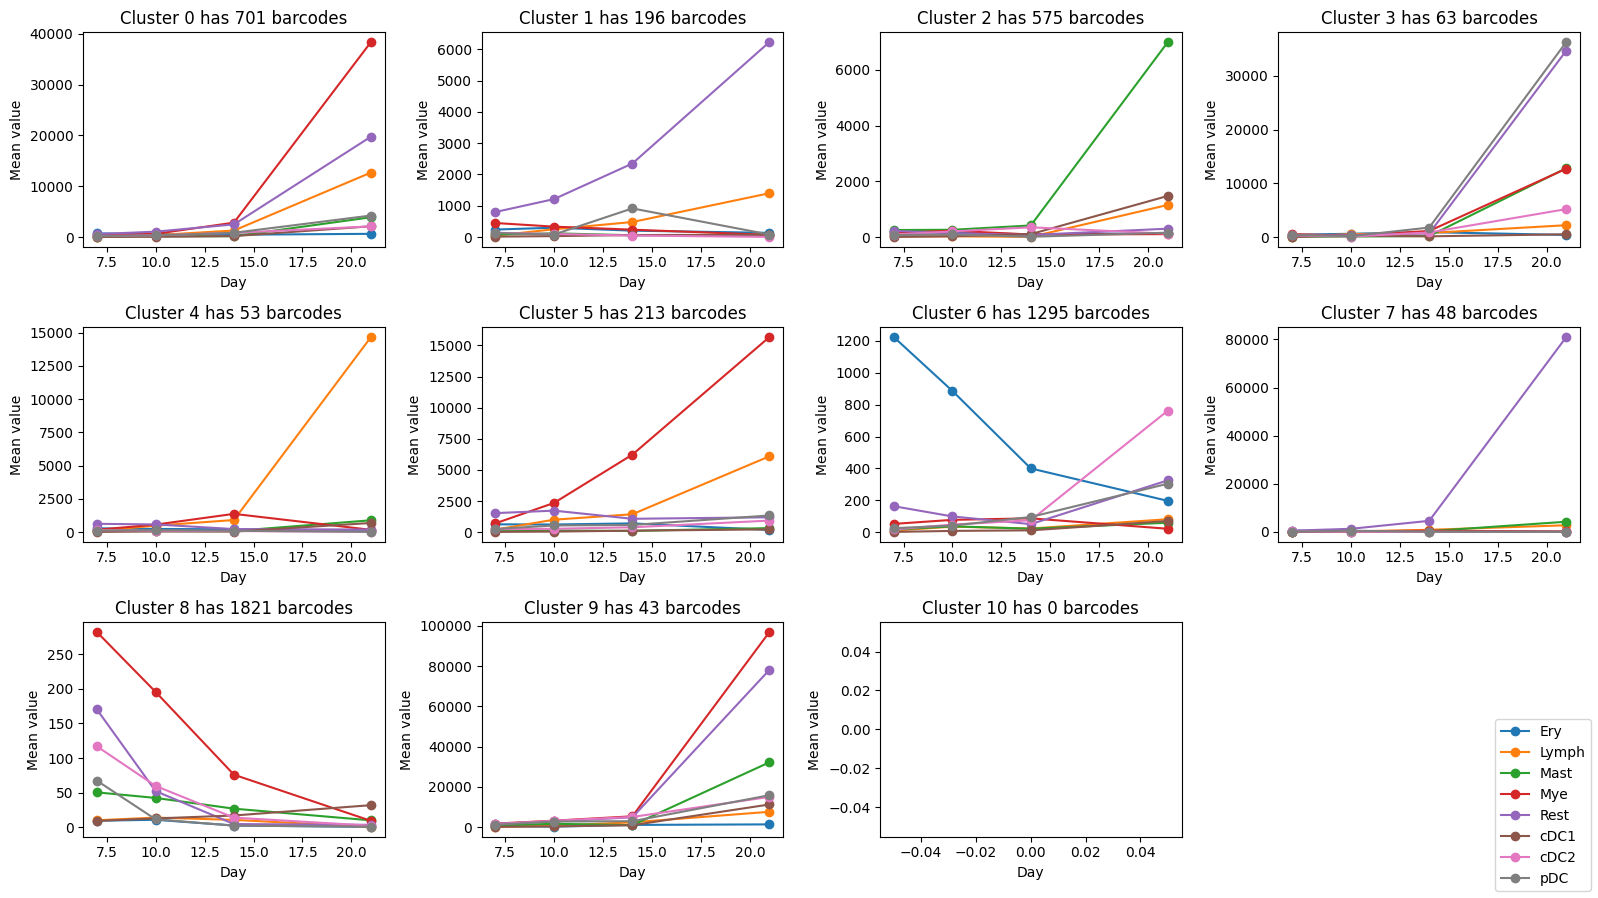

In [17]:
# plotting the day graphs

days_sorted = [f"D{d}" for d in DAYS]

n_clusters_actual = barcode_cluster_df["cluster"].nunique()
n_cols = 4
n_rows = int(np.ceil(n_clusters_actual / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3 * n_rows)
)

axes = np.asarray(axes).flatten()

for i in range(n_clusters_actual):
    ax = axes[i]

    members = barcode_cluster_df.loc[
        barcode_cluster_df["cluster"] == i,
        "barcode"
    ]

    n_bc = len(members)

    for lin in LINEAGE_NAMES:
        vals = wide.loc[members, lin][days_sorted].mean(axis=0)

        ax.plot(
            [7, 10, 14, 21],
            vals.values,
            marker="o",
            label=lin
        )

    ax.set_title(f"Cluster {i} has {n_bc} barcodes")
    ax.set_xlabel("Day")
    ax.set_ylabel("Mean value")

for j in range(n_clusters_actual, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right")

plt.tight_layout()
plt.show()


mofa groups=true may better be used for post hoc comparison. groups=true in mofa gives us within group variance and does not let us explore var between groups. look more into on tuesday TODO . 

In [18]:
DOM_THR = 0.5 # amt needed to make one cell unipotent

OVERRIDE = {} # dont agree w some labels so i can override here

# 0 gets flagged as multi so 50% of all are not mye even though inspection looks like myeloid. 

cluster_profiles = {}
cluster_auto_label = {}

for cl in sorted(barcode_cluster_df["cluster"].unique()):
    members = barcode_cluster_df.loc[barcode_cluster_df["cluster"] == cl, "barcode"]

    # total output per lineage, summed across days and members
    lineage_totals = pd.Series(0.0, index=LINEAGE_NAMES)
    for lin in LINEAGE_NAMES:
        lineage_totals[lin] = wide.loc[members, lin][days_sorted].sum().sum()

    total = lineage_totals.sum()
    if total <= 0:
        cluster_auto_label[cl] = "multipotent"
        cluster_profiles[cl] = lineage_totals
        continue

    top_lineage = lineage_totals.idxmax()
    top_share = lineage_totals[top_lineage] / total

    cluster_auto_label[cl] = (
        top_lineage if top_share >= DOM_THR else "multipotent"
    )
    cluster_profiles[cl] = lineage_totals

cluster_label_df = pd.DataFrame({
    "cluster": list(cluster_auto_label.keys()),
    "auto_label": list(cluster_auto_label.values()),
})
cluster_label_df["final_label"] = cluster_label_df.apply(
    lambda r: OVERRIDE.get(r["cluster"], r["auto_label"]), axis=1
)
cluster_label_df["n_barcodes"] = cluster_label_df["cluster"].map(
    barcode_cluster_df["cluster"].value_counts()
)

print(cluster_label_df.sort_values("cluster").to_string(index=False))
# barcode lvl fate label table: barcode -> group_label (Ery / Mast / ... / multipotent)


 cluster  auto_label final_label  n_barcodes
       0 multipotent multipotent         701
       1        Rest        Rest         196
       2        Mast        Mast         575
       3 multipotent multipotent          63
       4       Lymph       Lymph          53
       5         Mye         Mye         213
       6         Ery         Ery        1295
       7        Rest        Rest          48
       8 multipotent multipotent        1821
       9 multipotent multipotent          43
      11 multipotent multipotent          26


In [19]:
cluster_to_label = dict(zip(cluster_label_df["cluster"], cluster_label_df["final_label"]))

bc_fate_df = barcode_cluster_df.copy()

bc_fate_df["group_label"] = bc_fate_df["cluster"].map(cluster_to_label)

print(bc_fate_df["group_label"].value_counts())


group_label
multipotent    2654
Ery            1295
Mast            575
Rest            244
Mye             213
Lymph            53
Name: count, dtype: int64


In [20]:
PRIMARY_LABELS = ["Ery", "multipotent", "Mast"]
bc_fate_df["is_primary_contrast"] = bc_fate_df["group_label"].isin(PRIMARY_LABELS)
print()
print("Primary contrast (Ery vs multipotent) barcode counts:")
print(bc_fate_df.loc[bc_fate_df["is_primary_contrast"], "group_label"].value_counts())


Primary contrast (Ery vs multipotent) barcode counts:
group_label
multipotent    2654
Ery            1295
Mast            575
Name: count, dtype: int64


In [21]:
# pull out cons_bc present in annotated_2024

poss1 = pd.read_table("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/files/X_rna_counts_cell_ids.txt")
print(poss1.columns.tolist())
print("above is cols of cell_ids")

# mtx inspection 
print(rna_counts.obs_names)

['AAACCCAAGGTTAAAC-1']
above is cols of cell_ids
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '9758', '9759', '9760', '9761', '9762', '9763', '9764', '9765', '9766',
       '9767'],
      dtype='object', length=9768)


In [22]:
import scipy.io as sio

# unwrapping mtx file ;; using scipy.io instead of scanpy as easier


X = sio.mmread(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/files/X_rna_counts.mtx"
).tocsr()

gene_names = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/files/X_rna_counts_gene_names.txt",
    header=None
)[0].tolist()

cell_ids = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/files/X_rna_counts_cell_ids.txt",
    header=None
)[0].tolist()

assert X.shape == (len(cell_ids), len(gene_names)), (
    f"shape mismatch: X is {X.shape}, expected ({len(cell_ids)}, {len(gene_names)}) "
    f"-- if this fails, X may need X = X.T"
)

rna_counts = ad.AnnData(
    X=X,
    obs=pd.DataFrame(index=cell_ids),
    var=pd.DataFrame(index=gene_names),
)
print(rna_counts)

AnnData object with n_obs × n_vars = 9768 × 36601


JOINING FILES 

In [23]:
cell_to_meta = (adt_counts[["cell","cons_bc","donor_id","populations"]].drop_duplicates(subset="cell").set_index("cell"))

# print("RNA cell_ids  :", rna_counts.obs_names[:5].tolist())
# print("ADT 'cell' ids:", cell_to_meta.index[:5].tolist())
# same order 

rna_counts.obs["cons_bc"] = rna_counts.obs_names.map(cell_to_meta["cons_bc"]).str[:15]

rna_counts.obs["donor_id"] = rna_counts.obs_names.map(cell_to_meta["donor_id"])

rna_counts.obs["barcode_donor"] = (
    rna_counts.obs["cons_bc"].str.cat(rna_counts.obs["donor_id"], sep="_")
)
rna_counts.obs["populations"] = rna_counts.obs_names.map(cell_to_meta["populations"])
print(rna_counts.obs["populations"].value_counts(dropna=False))


populations
Mk                           1738
primitive-RBC                1322
Mk-ery_prog                  1239
Ery                          1079
early_lymphoid_progenitor     867
HSC                           855
basophil-mast_progenitor      712
pre-cDC                       593
CDP                           526
CD14+Monocyte                 441
CMP-GMP                       375
15                             21
Name: count, dtype: int64


In [24]:
n_matched = rna_counts.obs["cons_bc"].notna().sum()
print(f"{n_matched} / {rna_counts.n_obs} RNA cells matched to a cons_bc "
      f"({n_matched / rna_counts.n_obs:.1%})")
rna_counts.obs.head()
# 5509 / 9768 RNA cells matched to a cons_bc !!

5509 / 9768 RNA cells matched to a cons_bc (56.4%)


,cons_bc,donor_id,barcode_donor,populations
AAACCCAAGGTTAAAC-1,GTCTCGTTCTGGGTG,1,GTCTCGTTCTGGGTG_1,Mk
AAACCCACAAATCAAG-1,NaN,U,NaN,CDP
AAACCCACAAGTATCC-1,NaN,U,NaN,Mk-ery_prog
AAACCCACAGGTTACT-1,CCCTGGTTGTCTGTG,P,CCCTGGTTGTCTGTG_P,Mk
AAACCCACATGATCTG-1,AGGAGGGACATTCAG,1,AGGAGGGACATTCAG_1,early_lymphoid_progenitor


have mapped adt and rna to each other. now broadcast bc fade onto each, keep it as a post hoc analysis tool , not meant for model atm. 

In [25]:
bc_fate_df["group_label"]
bc_fate_df["barcode"]

0       AAACAAACGAGGGAT_U
1       AAACAAACTTGGAAT_U
2       AAACAAAGTAGGCAG_U
3       AAACAAGCGTAGTAG_U
4       AAACAAGGCTCGGAG_U
              ...        
5029    TGACACCCTGCTACA_V
5030    TGAGTCAGAGAGTGA_V
5031    TTAGAATCACAGAGA_V
5032    TTTCTTTCTGGATGT_V
5033    TTTGTCCGTCGGTCA_V
Name: barcode, Length: 5034, dtype: object

In [26]:
rna_counts.obs.columns

Index(['cons_bc', 'donor_id', 'barcode_donor', 'populations'], dtype='object')

In [27]:
barcode_to_group = dict(zip(bc_fate_df["barcode"], bc_fate_df["group_label"]))

rna_counts.obs["fate_group"] = rna_counts.obs["barcode_donor"].map(barcode_to_group)

n_labelled = rna_counts.obs["fate_group"].notna().sum()
print(f"{n_labelled} / {rna_counts.n_obs} cells received a fate label "
      f"({n_labelled / rna_counts.n_obs:.1%})")
print(rna_counts.obs["fate_group"].value_counts(dropna=False))



1821 / 9768 cells received a fate label (18.6%)
fate_group
NaN            7947
multipotent     655
Ery             568
Mast            343
Rest            143
Mye              88
Lymph            24
Name: count, dtype: int64


TODO CHECK. we see lot of NaN values- lots of non read barcodes. only 1821/8768 is this ok? 

comparison between multi / ery / mast for now. 

# mofa fitting ! :)

steps r subsetting hsc , normalise , find hvgs 


relaxing the hsc filter, trying to run it on all cells. 

fate_group
NaN            7947
multipotent     655
Ery             568
Mast            343
Rest            143
Mye              88
Lymph            24
Name: count, dtype: int64
fate_group
NaN            165
multipotent     67
Mast            14
Mye             12
Rest            10
Ery              5
Lymph            4

i.e. hsc filtering dropped 90% of previously ery. 

In [28]:
import mudata as mu
import scipy.sparse as sp

In [29]:
# performing cpm log normalisation 
#rna_hsc = rna_counts[rna_counts.obs["populations"] == "HSC"].copy()
rna_hsc = rna_counts.copy()
#rna_hsc = rna_counts[rna_counts.obs["populations"] == "HSC"].copy()
print(f"RNA restricted to HSC: {rna_hsc.n_obs} cells")

# sc.pp.normalize_total(rna_hsc, target_sum=1e6)
sc.pp.normalize_total(rna_hsc, target_sum=1e4)
sc.pp.log1p(rna_hsc)
sc.pp.highly_variable_genes(rna_hsc, n_top_genes=2000)
rna_hsc = rna_hsc[:, rna_hsc.var["highly_variable"]].copy()

RNA restricted to HSC: 9768 cells


In [30]:
# converting into type anndata for adt 
# adt_meta_cols = {"cons_bc", "donor_id", "barcode_donor", "populations"}
# adt_marker_cols = [c for c in adt_obj.columns if c not in adt_meta_cols]
# CAUSES ISSUE RUNNING MOFA BC CELL COLUMN IS NON NUMERIC

adt_meta_cols = {"cell", "cons_bc", "donor_id", "barcode_donor", "populations"}
adt_marker_cols = [c for c in adt_obj.columns if c not in adt_meta_cols]
adt_marker_cols = adt_obj[adt_marker_cols].select_dtypes(include="number").columns.tolist()
print(len(adt_marker_cols), "marker columns retained")

adt_indexed = adt_obj.set_index("cell")

# ERROR IN JOINING HERE ;; 
# "cell" should already be unique (one row per physical cell)
# If it isn't, that's worth knowing about rather than silently dropping rows.
n_dup = adt_indexed.index.duplicated().sum()
if n_dup:
    print(f"WARNING: {n_dup} duplicate 'cell' IDs in ADT table - inspect these before proceeding")
adt_indexed = adt_indexed[~adt_indexed.index.duplicated(keep="first")]

adt_ad = ad.AnnData(
    X=adt_indexed[adt_marker_cols].values,
    obs=adt_indexed[["cons_bc", "donor_id", "barcode_donor", "populations"]].copy(),
    var=pd.DataFrame(index=adt_marker_cols),
)
print(adt_ad)



177 marker columns retained
AnnData object with n_obs × n_vars = 5509 × 177
    obs: 'cons_bc', 'donor_id', 'barcode_donor', 'populations'


In [31]:
# common_bc = sorted(set(rna_hsc.obs["barcode_donor"]) & set(adt_ad.obs_names))
# print(f"{len(common_bc)} barcode_donor IDs shared between RNA and ADT")

# rna_aligned = rna_hsc[rna_hsc.obs["barcode_donor"].isin(common_bc)].copy()
# rna_aligned.obs_names = rna_aligned.obs["barcode_donor"].values
# rna_aligned = rna_aligned[~rna_aligned.obs_names.duplicated(keep="first")]

# adt_aligned = adt_ad[adt_ad.obs_names.isin(common_bc)].copy()

# # reindex both to the same cell order
# shared_order = [bc for bc in common_bc if bc in rna_aligned.obs_names and bc in adt_aligned.obs_names]
# rna_aligned = rna_aligned[shared_order].copy()
# adt_aligned = adt_aligned[shared_order].copy()

# mdata = mu.MuData({"RNA": rna_aligned, "ADT": adt_aligned})
# mdata.obs["group"] = "all"  # single group, deliberately - see methodology note above

# # carry the fate label along as metadata for the post-hoc step, NOT as a model input
# mdata.obs["fate_group"] = rna_aligned.obs["fate_group"].values

# print(mdata)
# print(mdata.obs["fate_group"].value_counts(dropna=False))

In [32]:
common_cells = sorted(set(rna_hsc.obs_names) & set(adt_ad.obs_names))
print(f"{len(common_cells)} cells shared between RNA and ADT (HSC-only, true per-cell pairing)")

rna_aligned = rna_hsc[common_cells].copy()
adt_aligned = adt_ad[common_cells].copy()

assert list(rna_aligned.obs_names) == list(adt_aligned.obs_names), "RNA/ADT cell order mismatch!"

# normalise + HVGs computed on THIS final subset
sc.pp.normalize_total(rna_aligned, target_sum=1e4)
sc.pp.log1p(rna_aligned)
sc.pp.highly_variable_genes(rna_aligned, n_top_genes=2000)
rna_aligned = rna_aligned[:, rna_aligned.var["highly_variable"]].copy()

# any 0 var? 
X_check = rna_aligned.X.toarray() if sp.issparse(rna_aligned.X) else rna_aligned.X
n_zero_var = (X_check.std(axis=0) == 0).sum()
print(f"{n_zero_var} / {rna_aligned.shape[1]} selected genes are zero-variance in this subset "
      f"({'good' if n_zero_var == 0 else 'still worth investigating'})")

mdata = mu.MuData({"RNA": rna_aligned, "ADT": adt_aligned})
mdata.obs["group"] = "all"
mdata.obs["fate_group"] = rna_aligned.obs["fate_group"].values

print(mdata)
print(mdata.obs["fate_group"].value_counts(dropna=False))

5509 cells shared between RNA and ADT (HSC-only, true per-cell pairing)


/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/mofa_venv/lib64/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:412: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(msg, UserWarning)


0 / 1918 selected genes are zero-variance in this subset (good)
MuData object with n_obs × n_vars = 5509 × 2095
  obs:	'group', 'fate_group'
  2 modalities
    RNA:	5509 x 1918
      obs:	'cons_bc', 'donor_id', 'barcode_donor', 'populations', 'fate_group'
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg'
    ADT:	5509 x 177
      obs:	'cons_bc', 'donor_id', 'barcode_donor', 'populations'
fate_group
NaN            3688
multipotent     655
Ery             568
Mast            343
Rest            143
Mye              88
Lymph            24
Name: count, dtype: int64


112 only is back to bite us ;; getting rid of NaN would lead to 112 only. for now moving without that. 

In [33]:
type(mdata)
mdata
mdata.mod.keys()
rna = mdata["RNA"]
adt = mdata["ADT"]

print(rna.shape, type(rna.X))
print(adt.shape, type(adt.X))



(5509, 1918) <class 'scipy.sparse._csr.csr_matrix'>
(5509, 177) <class 'numpy.ndarray'>


In [ ]:
import numpy as np
import scipy.sparse as sp
from mofapy2.run.entry_point import entry_point

rna = mdata["RNA"]
adt = mdata["ADT"]

# sparce matrix issue, just using numpy arr
rna_X = rna.X.toarray() if sp.issparse(rna.X) else np.asarray(rna.X)
adt_X = adt.X.toarray() if sp.issparse(adt.X) else np.asarray(adt.X)

print("RNA:", rna_X.shape)  # (277, 2000)
print("ADT:", adt_X.shape)  # (277, 180)

data = [[rna_X], [adt_X]]   # was: data = [rna_X, adt_X]

ent = entry_point()

ent.set_data_options(
    scale_views=True
)

ent.set_data_matrix(
    data=data,
    likelihoods=["gaussian", "gaussian"],
    views_names=["RNA", "ADT"],
    groups_names=["group1"],
    samples_names=[list(rna.obs_names)],
    features_names=[
        list(rna.var_names),
        list(adt.var_names)
    ]
)

ent.set_model_options(
    factors=15,
    spikeslab_weights=True,
    ard_weights=True
)

ent.set_train_options(
    iter=1000,
    convergence_mode="fast",
    seed=42
)

ent.build()
ent.run()


#ent.save("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/hdf5/mofa_3sep_all.hdf5")

RNA: (5509, 1918)
ADT: (5509, 177)

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Scaling views to unit variance...

Successfully loaded view='RNA' group='group1' with N=5509 samples and D=1918 features...
Successfully loaded view='ADT' group='group1' with N=5509 samples and D=177 features...


Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: Tr

# analysis!! importing from model mofa_gr.hdf5

In [34]:
import mofax as mfx
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

m = mfx.mofa_model("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/hdf5/mofa_3sep_all.hdf5")


In [35]:
mdata = mu.MuData({"RNA": rna_aligned, "ADT": adt_aligned})
mdata.obs["group"] = "all"  # single group, deliberately - see methodology note above

# carry the fate label along as metadata for the post-hoc step, NOT as a model input
mdata.obs["fate_group"] = rna_aligned.obs["fate_group"].values

In [36]:

Z = m.get_factors(df=True)  # cells x factors
Z["fate_group"] = mdata.obs.loc[Z.index, "fate_group"].values

Z_primary = Z[Z["fate_group"].isin(PRIMARY_LABELS)].dropna(subset=["fate_group"])
print(Z_primary["fate_group"].value_counts())

fate_group
multipotent    655
Ery            568
Mast           343
Name: count, dtype: int64


In [42]:
factor_cols = [c for c in Z_primary.columns if c != "fate_group"]

test_results = []
for factor in factor_cols:
    z_ery = Z_primary.loc[Z_primary["fate_group"] == "Ery", factor]
    z_multi = Z_primary.loc[Z_primary["fate_group"] == "multipotent", factor]

    if len(z_ery) < 5 or len(z_multi) < 5:
        continue

    stat, p = mannwhitneyu(z_ery, z_multi, alternative="two-sided")
    test_results.append({
        "factor": factor,
        "n_ery": len(z_ery),
        "n_multi": len(z_multi),
        "median_ery": z_ery.median(),
        "median_multi": z_multi.median(),
        "median_diff": z_ery.median() - z_multi.median(),
        "p": p,
    })

results_df = pd.DataFrame(test_results)
_, results_df["p_adj"], _, _ = multipletests(results_df["p"], method="fdr_bh")
results_df = results_df.sort_values("p_adj")

print(results_df.to_string(index=False))

SIG_FACTORS = results_df.loc[results_df["p_adj"] < 0.01, "factor"].tolist()
print(f"\nSignificant factors (FDR < 0.05): {SIG_FACTORS}")

  factor  n_ery  n_multi  median_ery  median_multi  median_diff            p        p_adj
 Factor2    568      655    1.169837     -0.557855     1.727693 5.411312e-83 8.116968e-82
 Factor3    568      655   -0.870460     -0.064513    -0.805947 3.677036e-61 2.757777e-60
 Factor4    568      655   -0.426878     -0.087217    -0.339661 5.283054e-25 2.641527e-24
 Factor5    568      655   -0.167958      0.339293    -0.507251 1.238212e-21 4.643294e-21
 Factor6    568      655    0.015748      0.153244    -0.137497 1.711091e-09 5.133273e-09
Factor14    568      655    0.032103      0.105705    -0.073602 7.753251e-07 1.938313e-06
 Factor1    568      655   -0.194524      0.169763    -0.364287 9.901296e-07 2.121706e-06
 Factor9    568      655   -0.007931      0.084074    -0.092005 2.145617e-03 4.008304e-03
Factor10    568      655    0.016495      0.093975    -0.077480 2.404983e-03 4.008304e-03
Factor11    568      655   -0.002009      0.046047    -0.048055 1.088321e-02 1.632482e-02
Factor15  

In [43]:
# how many Ery-labelled cells existed before RNA-ADT alignment?
print(rna_counts.obs["fate_group"].value_counts(dropna=False))

# vs how many survived into rna_aligned / mdata
print(rna_aligned.obs["fate_group"].value_counts(dropna=False))

pd.crosstab(rna_counts.obs["populations"], rna_counts.obs["fate_group"], dropna=False)

fate_group
NaN            7947
multipotent     655
Ery             568
Mast            343
Rest            143
Mye              88
Lymph            24
Name: count, dtype: int64
fate_group
NaN            3688
multipotent     655
Ery             568
Mast            343
Rest            143
Mye              88
Lymph            24
Name: count, dtype: int64


fate_group,Ery,Lymph,Mast,Mye,Rest,multipotent,NaN
populations,,,,,,,
15,0,0,0,1,0,4,16
CD14+Monocyte,3,0,0,5,2,17,414
CDP,1,2,1,3,2,14,503
CMP-GMP,6,1,0,5,6,43,314
Ery,158,0,38,5,3,25,850
HSC,10,12,31,20,15,121,646
Mk,55,0,73,12,40,152,1406
Mk-ery_prog,110,4,49,7,31,70,968
basophil-mast_progenitor,17,0,69,3,1,39,583


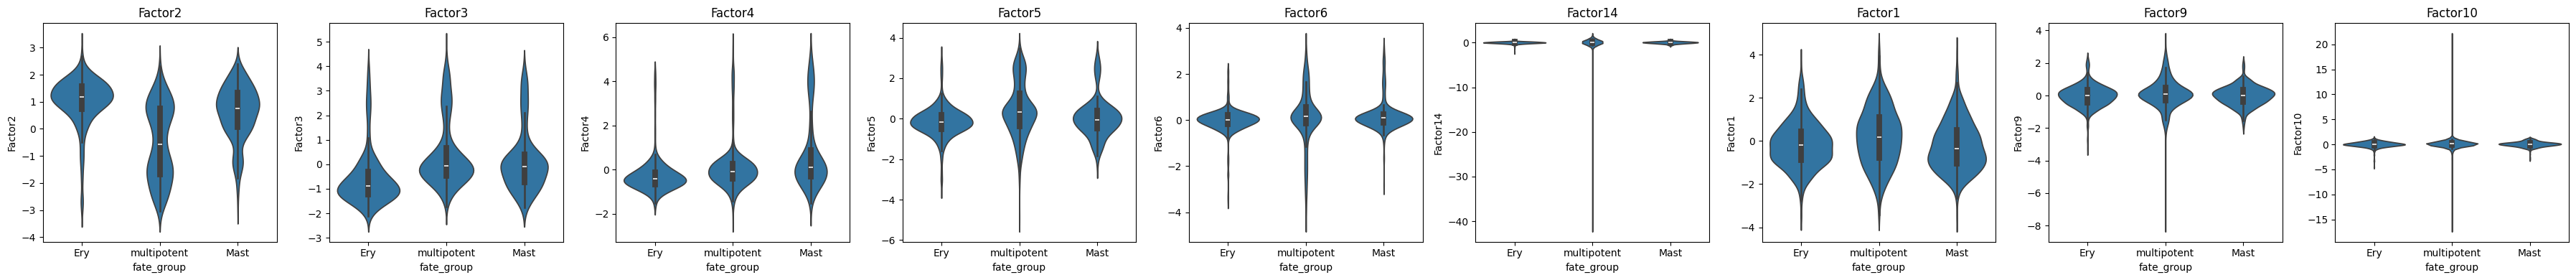

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

if SIG_FACTORS:
    n = len(SIG_FACTORS)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), squeeze=False)
    for ax, factor in zip(axes[0], SIG_FACTORS):
        sns.violinplot(data=Z_primary, x="fate_group", y=factor, ax=ax, order=PRIMARY_LABELS)
        ax.set_title(factor)
    plt.tight_layout()
    plt.show()
else:
    print("No factors passed FDR < 0.05 - consider relaxing the threshold or "
          "revisiting the fate labels before concluding there's no signal.")

In [ ]:
# TOP_N = 10

# candidate_features = {}
# for factor in SIG_FACTORS:
# #for factor in SIG_FACTORS[1]:
#     w_rna = m.get_weights(views="RNA", factors=factor, df=True)[factor]
#     w_adt = m.get_weights(views="ADT", factors=factor, df=True)[factor]

#     top_rna = w_rna.reindex(w_rna.abs().sort_values(ascending=False).index)[:TOP_N]
#     top_adt = w_adt.reindex(w_adt.abs().sort_values(ascending=False).index)[:TOP_N]

#     candidate_features[factor] = {"RNA": top_rna, "ADT": top_adt}

#     print(f"=== {factor} ===")
#     print("Top RNA features:")
#     print(top_rna)
#     print("Top ADT features:")
#     print(top_adt)
#     print()

=== Factor2 ===
Top RNA features:
XACT        1.225335
WNT5B       1.107165
HBA1        1.061294
SLC40A1     1.050464
RYR3        1.039834
NFIA        1.037841
STON2       0.958813
ZNF521      0.957540
TYROBP     -0.921901
TIMP3       0.915221
DPP10       0.899757
HBD         0.898905
HBA2        0.895730
PRKAR2B     0.892354
SLC25A21    0.873951
TFRC        0.867142
RHAG        0.839335
ZNF385D     0.830458
HDAC9      -0.805540
HBG2        0.801425
CD48       -0.800845
JAML       -0.793197
IPCEF1     -0.778215
HBG1        0.772992
IFI30      -0.769493
Name: Factor2, dtype: float64
Top ADT features:
nCount_RNA        5.251780
nFeature_RNA      0.801085
nCount_ADT       -0.045582
Unnamed: 0       -0.007303
Hu.CD71          -0.003549
Hu.CD305-LAIR1   -0.003444
Hu.CD45RA        -0.003258
Hu.CLEC12A       -0.003166
Hu.CD48          -0.003043
Hu.CD11a         -0.002994
Hu.CD31          -0.002815
Hu.CD18          -0.002557
Hu.CD141         -0.002551
Hu.CD192         -0.002381
Hu.CD123       

In [51]:
TOP_N = 10
candidate_features = {}

factor = SIG_FACTORS[2] 

w_rna = m.get_weights(views="RNA", factors=factor, df=True)[factor]
w_adt = m.get_weights(views="ADT", factors=factor, df=True)[factor]

top_rna = w_rna.reindex(w_rna.abs().sort_values(ascending=False).index)[:TOP_N]
top_adt = w_adt.reindex(w_adt.abs().sort_values(ascending=False).index)[:TOP_N]

candidate_features[factor] = {"RNA": top_rna, "ADT": top_adt}

print(f"=== {factor} ===")
print("Top RNA features:")
print(top_rna)
print("Top ADT features:")
print(top_adt)
print()


=== Factor4 ===
Top RNA features:
HPGDS     0.946130
KRT1      0.884691
CPA3      0.853143
CD36     -0.826486
HDC       0.819356
HPGD      0.819034
PRG2      0.778016
RHEX      0.774343
TPSB2     0.766003
TPSAB1    0.742653
Name: Factor4, dtype: float64
Top ADT features:
HuMs.CD44         0.002556
Hu.CD305-LAIR1    0.002496
Hu.CD36          -0.002278
Hu.CD84           0.002037
Hu.CD112          0.002002
Hu.KLRG1          0.001991
Hu.CD151         -0.001873
Hu.CD82          -0.001814
nFeature_ADT     -0.001669
Hu.CD33           0.001574
Name: Factor4, dtype: float64



      Factor View   Group         R2
0    Factor1  RNA  group1   4.205035
1    Factor1  ADT  group1  36.731059
2    Factor2  RNA  group1  11.972901
3    Factor2  ADT  group1  17.645292
4    Factor3  RNA  group1   6.353296
5    Factor3  ADT  group1   1.092967
6    Factor4  RNA  group1   3.176521
7    Factor4  ADT  group1   0.000088
8    Factor5  RNA  group1   2.146298
9    Factor5  ADT  group1   0.009645
10   Factor6  RNA  group1   1.194783
11   Factor6  ADT  group1   0.000183
12   Factor7  RNA  group1   1.070677
13   Factor7  ADT  group1   0.002349
14   Factor8  RNA  group1   0.739745
15   Factor8  ADT  group1   0.007766
16   Factor9  RNA  group1   0.212696
17   Factor9  ADT  group1   0.005346
18  Factor10  RNA  group1   0.127253
19  Factor10  ADT  group1   0.001984
20  Factor11  RNA  group1   0.106534
21  Factor11  ADT  group1   0.000691
22  Factor12  RNA  group1   0.097392
23  Factor12  ADT  group1  -0.000001
24  Factor13  RNA  group1   0.088661
25  Factor13  ADT  group1   0.000748
2

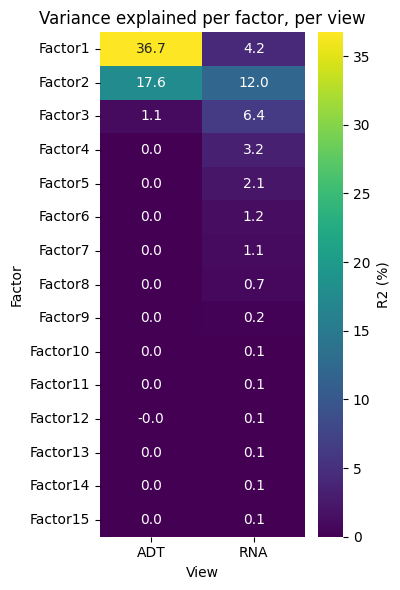

View
ADT    55.498870
RNA    31.618924
Name: R2, dtype: float64


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# per-factor, per-view variance explained (R2), as a DataFrame
r2 = m.get_r2()   # columns typically: Factor, View, Group, R2 (long format)
print(r2)

# pivot to Factor x View for a heatmap
r2_wide = r2.pivot_table(index="Factor", columns="View", values="R2")
# keep factors in numeric order (Factor1, Factor2, ... not alphabetical)
r2_wide = r2_wide.reindex(sorted(r2_wide.index, key=lambda f: int(f.replace("Factor", ""))))

fig, ax = plt.subplots(figsize=(4, 6))
sns.heatmap(r2_wide, annot=True, fmt=".1f", cmap="viridis", ax=ax, cbar_kws={"label": "R2 (%)"})
ax.set_title("Variance explained per factor, per view")
plt.tight_layout()
plt.show()

# total variance explained per view, summed across all factors
print(r2.groupby("View")["R2"].sum())